In [1]:
from pathlib import Path
import json
import sys
from typing import Any, Mapping, Sequence

import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
import numpy as np
from IPython.display import Image, Markdown, display
from matplotlib.ticker import MaxNLocator, StrMethodFormatter

# ---------------------------------------------------------------------------
# Task-specific paths
# ---------------------------------------------------------------------------
PROJECT_ROOT = Path("/home/hieule/research/reflector-position")
ARTIFACTS_DIR = Path(
    "/home/hieule/research/reflector-position/tmp_comparison_results2/hrbb/per_trial_runs/aps_03_seed_0044/artifacts"
)
PER_TRIAL_RUNS_DIR = Path(
    "/home/hieule/research/reflector-position/tmp_comparison_results2/hrbb/per_trial_runs"
)
RUN_TAG = ARTIFACTS_DIR.parent.name
OUTPUT_DIR = PER_TRIAL_RUNS_DIR / "recreated_static_plots" / RUN_TAG

# Keep legend order aligned with attached static plots.
# kmeans is intentionally excluded for this notebook task.
METHOD_ORDER = ["memetic", "random", "weighted_kmeans", "random_gd", "pso_gd"]
EXCLUDED_METHODS = {"kmeans"}

# Fixed colors to keep style consistent across all figures.
METHOD_COLORS: dict[str, str] = {
    "memetic": "#1f77b4",        # blue
    "pso_gd": "#ff7f0e",         # orange
    "random_gd": "#2ca02c",      # green
    "weighted_kmeans": "#d62728",# red
    "random": "#9467bd",         # purple
}

# Moving-average smoothing window (>=1). Use 1 to disable smoothing.
SMOOTHING_WINDOW = 7

# ---------------------------------------------------------------------------
# Per-plot RSSI y-axis limits template.
# Edit each tuple independently: (y_min, y_max). Use None for matplotlib auto.
# ---------------------------------------------------------------------------
RSSI_Y_LIMITS_BY_PLOT: dict[str, tuple[float, float] | None] = {
    "all_methods_mean_rss_dbm_static.png": (-70.0, -45.0),
    "all_methods_min_rss_dbm_static.png": (-110.0, -70.0),
    "all_methods_p5_rss_dbm_static.png": (-100.0, -50.0),
    "all_methods_priority_mean_rss_dbm_static.png": (-70.0, -45.0),
    "all_methods_priority_min_rss_dbm_static.png": (-90.0, -60.0),
    "all_methods_priority_p5_rss_dbm_static.png": (-100.0, -50.0),
}

# Optional primary-loss range. Keep None for auto.
PRIMARY_Y_LIMITS: tuple[float, float] | None = (-0.05, 0.3)

# Make src-layout package importable from notebook.
SRC_DIR = PROJECT_ROOT / "src"
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

from reflector_position.optimizers.baselines.static_comparison_plotting import (
    _RSSI_METRIC_LABELS,
    _build_primary_loss_series,
    _build_rssi_metric_series,
    _display_method_name,
    _expand_single_point_series,
)

In [2]:
def _load_json(path: Path) -> Any:
    with path.open("r", encoding="utf-8") as f:
        return json.load(f)


def _set_integer_iteration_ticks(axis: plt.Axes) -> None:
    axis.xaxis.set_major_locator(MaxNLocator(integer=True))
    axis.xaxis.set_major_formatter(StrMethodFormatter("{x:.0f}"))


def _smooth_series(series: Sequence[float], window: int) -> np.ndarray:
    values = np.asarray(series, dtype=float)
    if values.size <= 2 or window <= 1:
        return values

    effective_window = max(1, min(int(window), int(values.size)))
    if effective_window <= 1:
        return values

    # Edge-padded moving average keeps output length unchanged and avoids endpoint drop.
    left_pad = effective_window // 2
    right_pad = effective_window - 1 - left_pad
    padded = np.pad(values, (left_pad, right_pad), mode="edge")
    kernel = np.ones(effective_window, dtype=float) / float(effective_window)
    return np.convolve(padded, kernel, mode="valid")


def discover_methods(
    artifacts_dir: Path,
    preferred_order: Sequence[str] | None = None,
    excluded_methods: set[str] | None = None,
) -> list[str]:
    excluded = {str(m) for m in (excluded_methods or set())}
    available_methods = sorted(
        p.name[: -len("_results.json")]
        for p in artifacts_dir.glob("*_results.json")
        if p.name.endswith("_results.json")
    )
    available_methods = [method for method in available_methods if method not in excluded]

    if preferred_order is None:
        return available_methods

    ordered = [method for method in preferred_order if method in available_methods]
    remaining = [method for method in available_methods if method not in ordered]
    return ordered + remaining


def load_method_artifacts(
    artifacts_dir: Path,
    methods: Sequence[str],
) -> tuple[dict[str, Mapping[str, Any]], dict[str, list[Mapping[str, Any]]]]:
    method_results: dict[str, Mapping[str, Any]] = {}
    method_trace_rows: dict[str, list[Mapping[str, Any]]] = {}

    for method in methods:
        result_path = artifacts_dir / f"{method}_results.json"
        trace_path = artifacts_dir / f"{method}_iteration_trace.json"

        if not result_path.exists():
            raise FileNotFoundError(f"Missing result file for method '{method}': {result_path}")

        result_payload = _load_json(result_path)
        if not isinstance(result_payload, Mapping):
            raise ValueError(f"Result file must contain a JSON object: {result_path}")

        if trace_path.exists():
            trace_payload = _load_json(trace_path)
        else:
            trace_payload = result_payload.get("iteration_trace", [])

        if not isinstance(trace_payload, list):
            trace_payload = []

        trace_rows = [row for row in trace_payload if isinstance(row, Mapping)]
        method_results[method] = dict(result_payload)
        method_trace_rows[method] = trace_rows

    return method_results, method_trace_rows


def _plot_primary_loss_comparison(
    methods: Sequence[str],
    method_results: Mapping[str, Mapping[str, Any]],
    method_trace_rows: Mapping[str, Sequence[Mapping[str, Any]]],
    output_dir: Path,
    primary_y_limits: tuple[float, float] | None = None,
    method_colors: Mapping[str, str] | None = None,
    smoothing_window: int = 1,
) -> Path | None:
    raw_series_map: dict[str, list[float]] = {}
    for method in methods:
        raw_series_map[method] = _build_primary_loss_series(
            method=method,
            trace_rows=method_trace_rows.get(method, []),
            result_payload=method_results.get(method, {}),
        )

    target_len = max((len(series) for series in raw_series_map.values()), default=0)
    if target_len < 1:
        return None

    fig, ax = plt.subplots(figsize=(12.0, 6.0))
    for method in methods:
        series = _expand_single_point_series(raw_series_map.get(method, []), target_len=target_len)
        if not series:
            continue
        x_values = np.arange(1, len(series) + 1, dtype=np.int64)
        smoothed = _smooth_series(series, window=smoothing_window)
        color = method_colors.get(method) if method_colors else None
        ax.plot(
            x_values,
            smoothed,
            linewidth=2.5,
            marker="o",
            markersize=4.5,
            color=color,
            label=_display_method_name(method),
        )

    if not ax.lines:
        plt.close(fig)
        return None
    # print("fasdfasd")
    # ax.set_title("Loss", fontsize=22.0)
    ax.set_xlabel("Iteration", fontsize=20.0)
    ax.set_ylabel("Loss", fontsize=20.0)
    # change font of tick labels to integer without decimal
    ax.tick_params(axis="both", which="major", labelsize=18.0)
    _set_integer_iteration_ticks(ax)
    if primary_y_limits is not None:
        ax.set_ylim(float(primary_y_limits[0]), float(primary_y_limits[1]))
    ax.grid(True, alpha=0.25)
    ax.legend(loc="lower left", fontsize=20.0)
    
    # split legend into multiple columns if there are more than 4 methods
    if len(methods) > 4:
        ax.legend(loc="lower left", fontsize=20.0, ncol=2)

    out_path = output_dir / "all_methods_primary_loss_static.png"
    fig.tight_layout()
    fig.savefig(out_path, dpi=300)
    plt.close(fig)
    return out_path


def _plot_cross_method_rssi_metric(
    methods: Sequence[str],
    method_results: Mapping[str, Mapping[str, Any]],
    method_trace_rows: Mapping[str, Sequence[Mapping[str, Any]]],
    metric_key: str,
    output_path: Path,
    y_limits: tuple[float, float] | None,
    method_colors: Mapping[str, str] | None = None,
    smoothing_window: int = 1,
) -> Path | None:
    raw_series_by_method: dict[str, list[float]] = {}
    for method in methods:
        trace_rows = method_trace_rows.get(method, [])
        fallback_len = max(1, len(trace_rows))
        raw_series_by_method[method] = _build_rssi_metric_series(
            method=method,
            trace_rows=trace_rows,
            result_payload=method_results.get(method, {}),
            metric_key=metric_key,
            fallback_length=fallback_len,
        )

    target_len = max((len(series) for series in raw_series_by_method.values()), default=0)
    if target_len < 1:
        return None

    fig, ax = plt.subplots(figsize=(12.0, 6.0))
    for method in methods:
        series = _expand_single_point_series(raw_series_by_method.get(method, []), target_len=target_len)
        if not series:
            continue
        x_values = np.arange(1, len(series) + 1, dtype=np.int64)
        smoothed = _smooth_series(series, window=smoothing_window)
        color = method_colors.get(method) if method_colors else None
        ax.plot(
            x_values,
            smoothed,
            linewidth=2.5,
            marker="o",
            markersize=4.5,
            color=color,
            label=_display_method_name(method),
        )

    if not ax.lines:
        plt.close(fig)
        return None

    metric_label = _RSSI_METRIC_LABELS.get(metric_key, metric_key)
    # ax.set_title(f"{metric_label}", fontsize=22.0)
    ax.set_xlabel("Iteration", fontsize=20.0)
    ax.set_ylabel("RSSI (dBm)", fontsize=20.0)
    # change font of tick labels to integer without decimal
    ax.tick_params(axis="both", which="major", labelsize=18.0)
    _set_integer_iteration_ticks(ax)
    if y_limits is not None:
        ax.set_ylim(float(y_limits[0]), float(y_limits[1]))
    ax.grid(True, alpha=0.25)
    ax.legend(loc="lower left", fontsize=20.0)

    # split legend into multiple columns if there are more than 4 methods
    if len(methods) > 4:
        ax.legend(loc="lower left", fontsize=20.0, ncol=2)
        
    fig.tight_layout()
    fig.savefig(output_path, dpi=300)
    plt.close(fig)
    return output_path


def recreate_static_plots_from_trial_artifacts(
    artifacts_dir: Path,
    output_dir: Path,
    method_order: Sequence[str] | None = None,
    excluded_methods: set[str] | None = None,
    rssi_y_limits_by_plot: Mapping[str, tuple[float, float] | None] | None = None,
    primary_y_limits: tuple[float, float] | None = None,
    method_colors: Mapping[str, str] | None = None,
    smoothing_window: int = 1,
) -> dict[str, Any]:
    methods = discover_methods(
        artifacts_dir=artifacts_dir,
        preferred_order=method_order,
        excluded_methods=excluded_methods,
    )
    method_results, method_trace_rows = load_method_artifacts(
        artifacts_dir=artifacts_dir,
        methods=methods,
    )

    output_dir.mkdir(parents=True, exist_ok=True)
    limits_map = dict(rssi_y_limits_by_plot or {})

    metric_to_filename = {
        "mean_rss_dbm": "all_methods_mean_rss_dbm_static.png",
        "min_rss_dbm": "all_methods_min_rss_dbm_static.png",
        "p5_rss_dbm": "all_methods_p5_rss_dbm_static.png",
        "priority_mean_rss_dbm": "all_methods_priority_mean_rss_dbm_static.png",
        "priority_min_rss_dbm": "all_methods_priority_min_rss_dbm_static.png",
        "priority_p5_rss_dbm": "all_methods_priority_p5_rss_dbm_static.png",
    }

    rssi_plot_paths: dict[str, str | None] = {}
    for metric_key, filename in metric_to_filename.items():
        y_limits = limits_map.get(filename)
        saved_path = _plot_cross_method_rssi_metric(
            methods=methods,
            method_results=method_results,
            method_trace_rows=method_trace_rows,
            metric_key=metric_key,
            output_path=output_dir / filename,
            y_limits=y_limits,
            method_colors=method_colors,
            smoothing_window=smoothing_window,
        )
        rssi_plot_paths[metric_key] = str(saved_path) if saved_path is not None else None

    primary_path = _plot_primary_loss_comparison(
        methods=methods,
        method_results=method_results,
        method_trace_rows=method_trace_rows,
        output_dir=output_dir,
        primary_y_limits=primary_y_limits,
        method_colors=method_colors,
        smoothing_window=smoothing_window,
    )

    plot_artifacts = {
        "all_methods_primary_loss_static_png": str(primary_path) if primary_path is not None else None,
        "all_methods_rssi_metric_static_png": {
            key: rssi_plot_paths[key] for key in ("mean_rss_dbm", "min_rss_dbm", "p5_rss_dbm")
        },
        "all_methods_priority_rssi_metric_static_png": {
            key: rssi_plot_paths[key]
            for key in ("priority_mean_rss_dbm", "priority_min_rss_dbm", "priority_p5_rss_dbm")
        },
    }

    manifest = {
        "artifacts_dir": str(artifacts_dir),
        "output_dir": str(output_dir),
        "methods": methods,
        "excluded_methods": sorted(excluded_methods or []),
        "rssi_y_limits_by_plot": {
            k: [float(v[0]), float(v[1])] if v is not None else None for k, v in limits_map.items()
        },
        "primary_y_limits": [float(primary_y_limits[0]), float(primary_y_limits[1])] if primary_y_limits else None,
        "smoothing_window": int(smoothing_window),
        "method_colors": dict(method_colors or {}),
        "plot_artifacts": plot_artifacts,
    }
    manifest_path = output_dir / "recreated_plot_manifest.json"
    manifest_path.write_text(json.dumps(manifest, indent=2), encoding="utf-8")

    return {
        "methods": methods,
        "output_dir": output_dir,
        "manifest_path": manifest_path,
        "plot_artifacts": plot_artifacts,
    }


def _collect_png_paths(value: Any) -> list[Path]:
    if isinstance(value, str) and value.endswith(".png"):
        path = Path(value)
        return [path] if path.exists() else []
    if isinstance(value, Mapping):
        paths: list[Path] = []
        for nested in value.values():
            paths.extend(_collect_png_paths(nested))
        return paths
    if isinstance(value, list):
        paths = []
        for nested in value:
            paths.extend(_collect_png_paths(nested))
        return paths
    return []


def display_recreated_cross_method_plots(plot_artifacts: Mapping[str, Any]) -> None:
    all_png_paths = _collect_png_paths(plot_artifacts)

    cross_method_paths = [
        path for path in all_png_paths if path.name.startswith("all_methods_") and path.name.endswith("_static.png")
    ]

    order = [
        "all_methods_p5_rss_dbm_static.png",
        "all_methods_min_rss_dbm_static.png",
        "all_methods_mean_rss_dbm_static.png",
        "all_methods_priority_p5_rss_dbm_static.png",
        "all_methods_priority_min_rss_dbm_static.png",
        "all_methods_priority_mean_rss_dbm_static.png",
        "all_methods_primary_loss_static.png",
    ]
    order_index = {name: i for i, name in enumerate(order)}
    cross_method_paths = sorted(
        set(cross_method_paths),
        key=lambda path: (order_index.get(path.name, 999), path.name),
    )

    if not cross_method_paths:
        display(Markdown("No cross-method plots were generated."))
        return

    display(Markdown("## Recreated Cross-Method Static Plots"))
    for path in cross_method_paths:
        display(Markdown(f"### {path.name}"))
        display(Image(filename=str(path)))

Methods used: ['memetic', 'random', 'weighted_kmeans', 'random_gd', 'pso_gd']
Output directory: /home/hieule/research/reflector-position/tmp_comparison_results2/hrbb/per_trial_runs/recreated_static_plots/aps_03_seed_0044
Manifest: /home/hieule/research/reflector-position/tmp_comparison_results2/hrbb/per_trial_runs/recreated_static_plots/aps_03_seed_0044/recreated_plot_manifest.json


## Recreated Cross-Method Static Plots

### all_methods_p5_rss_dbm_static.png

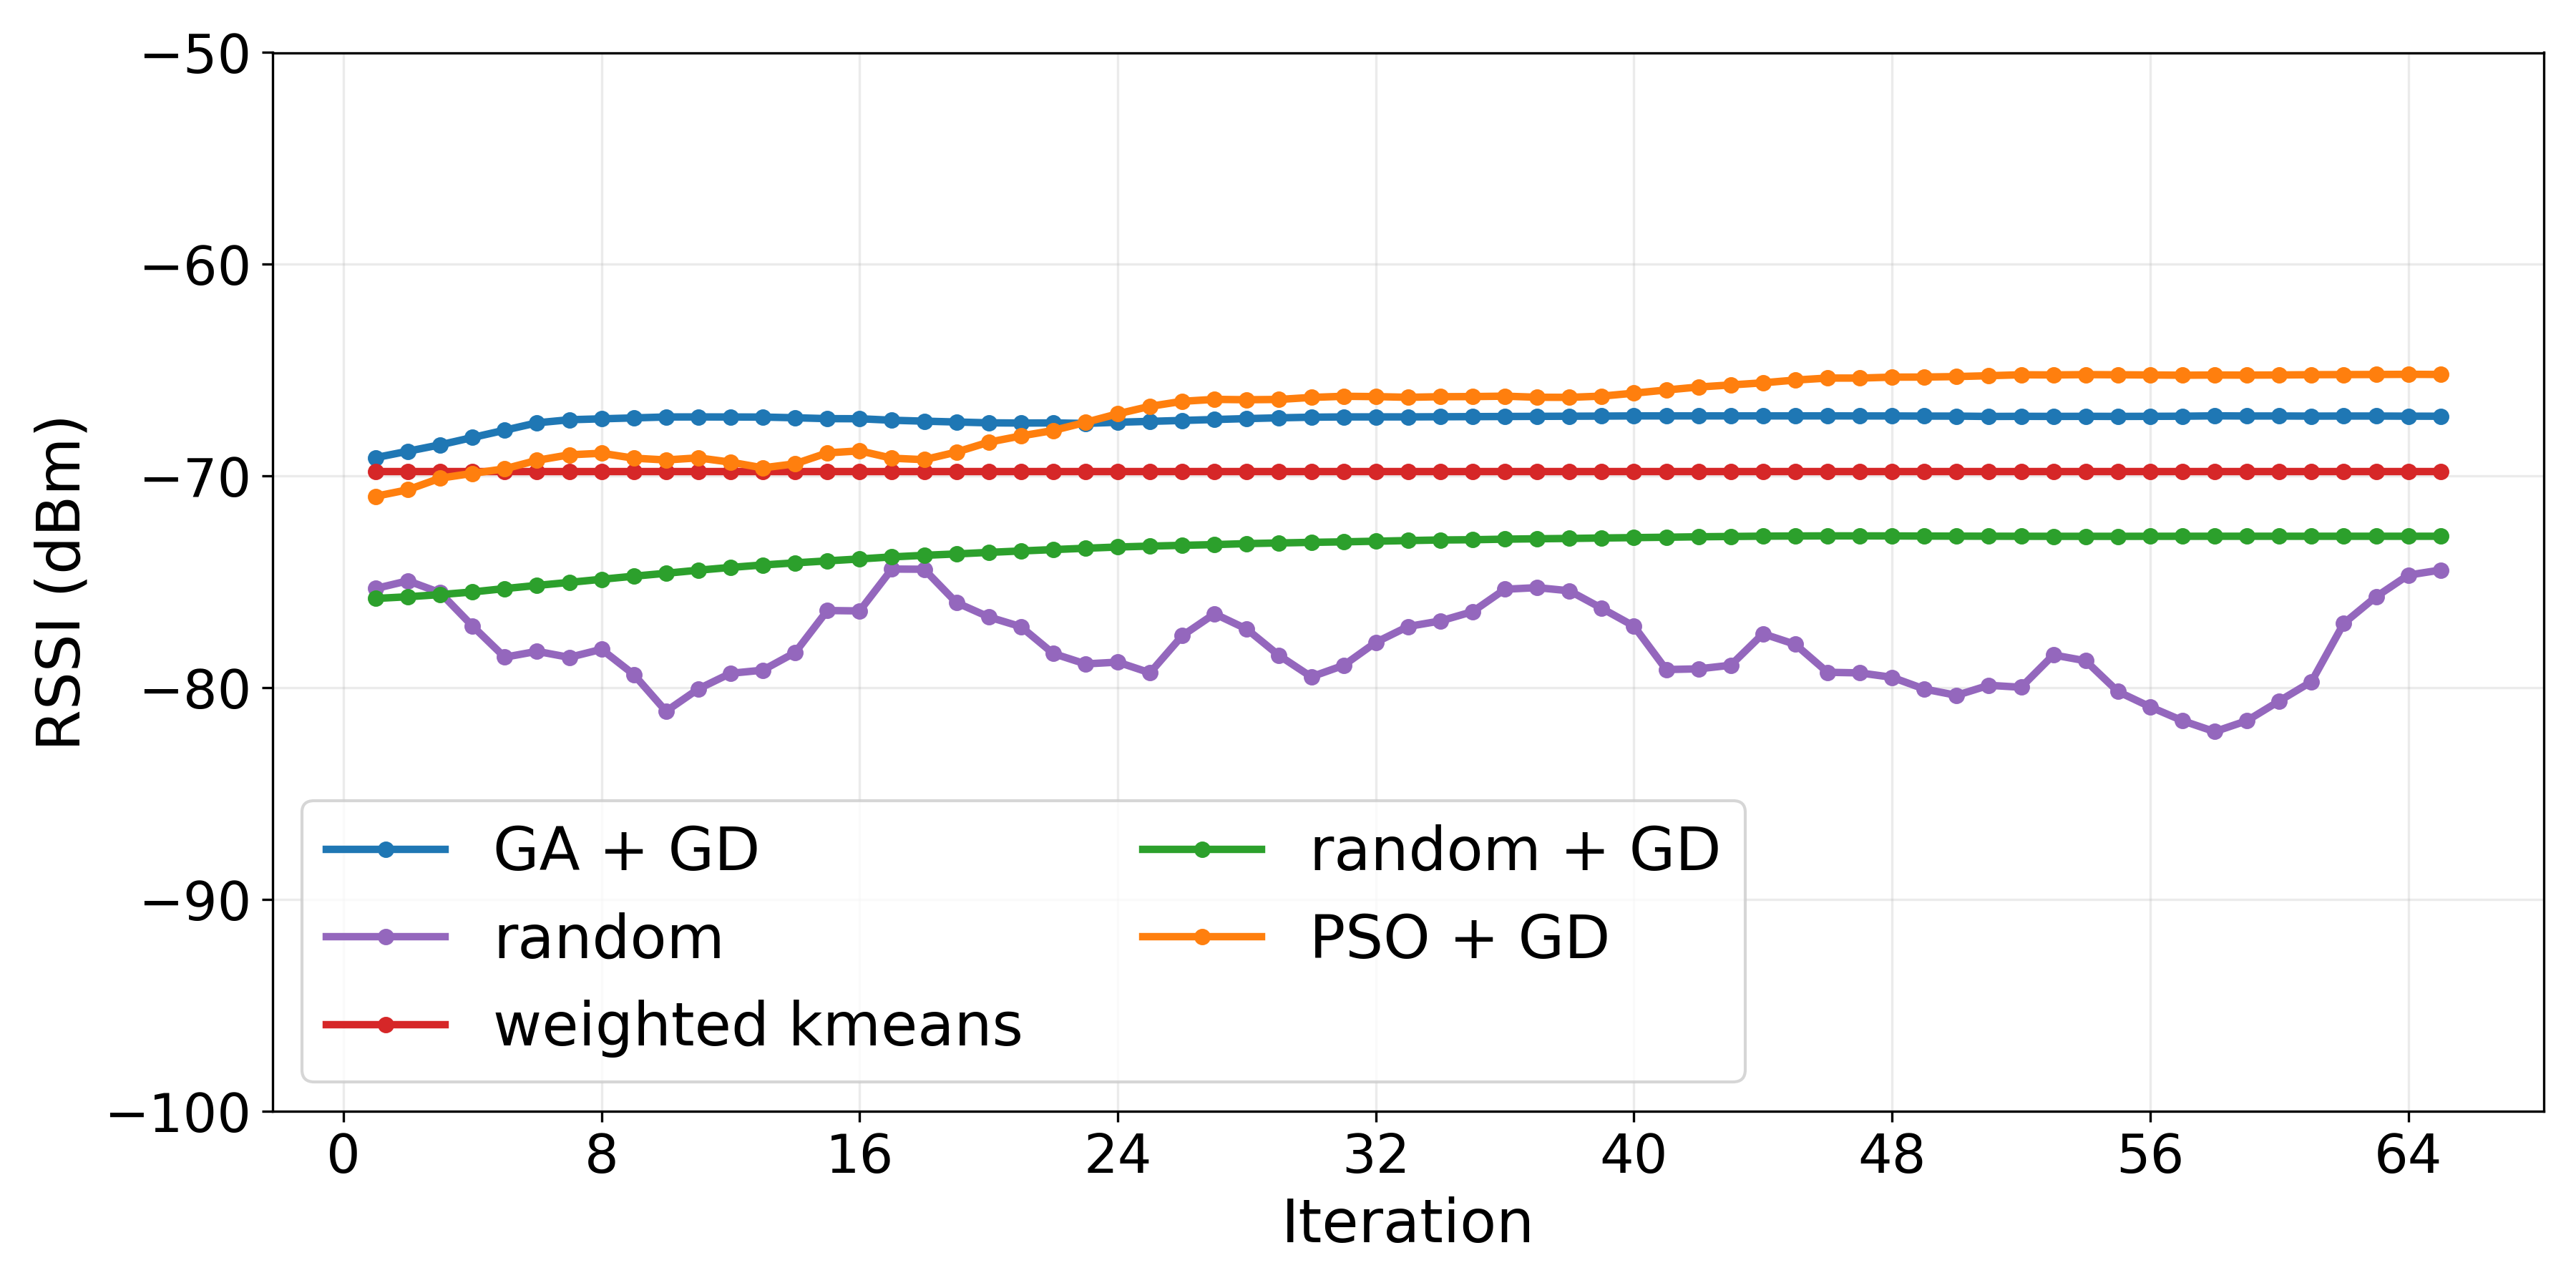

### all_methods_min_rss_dbm_static.png

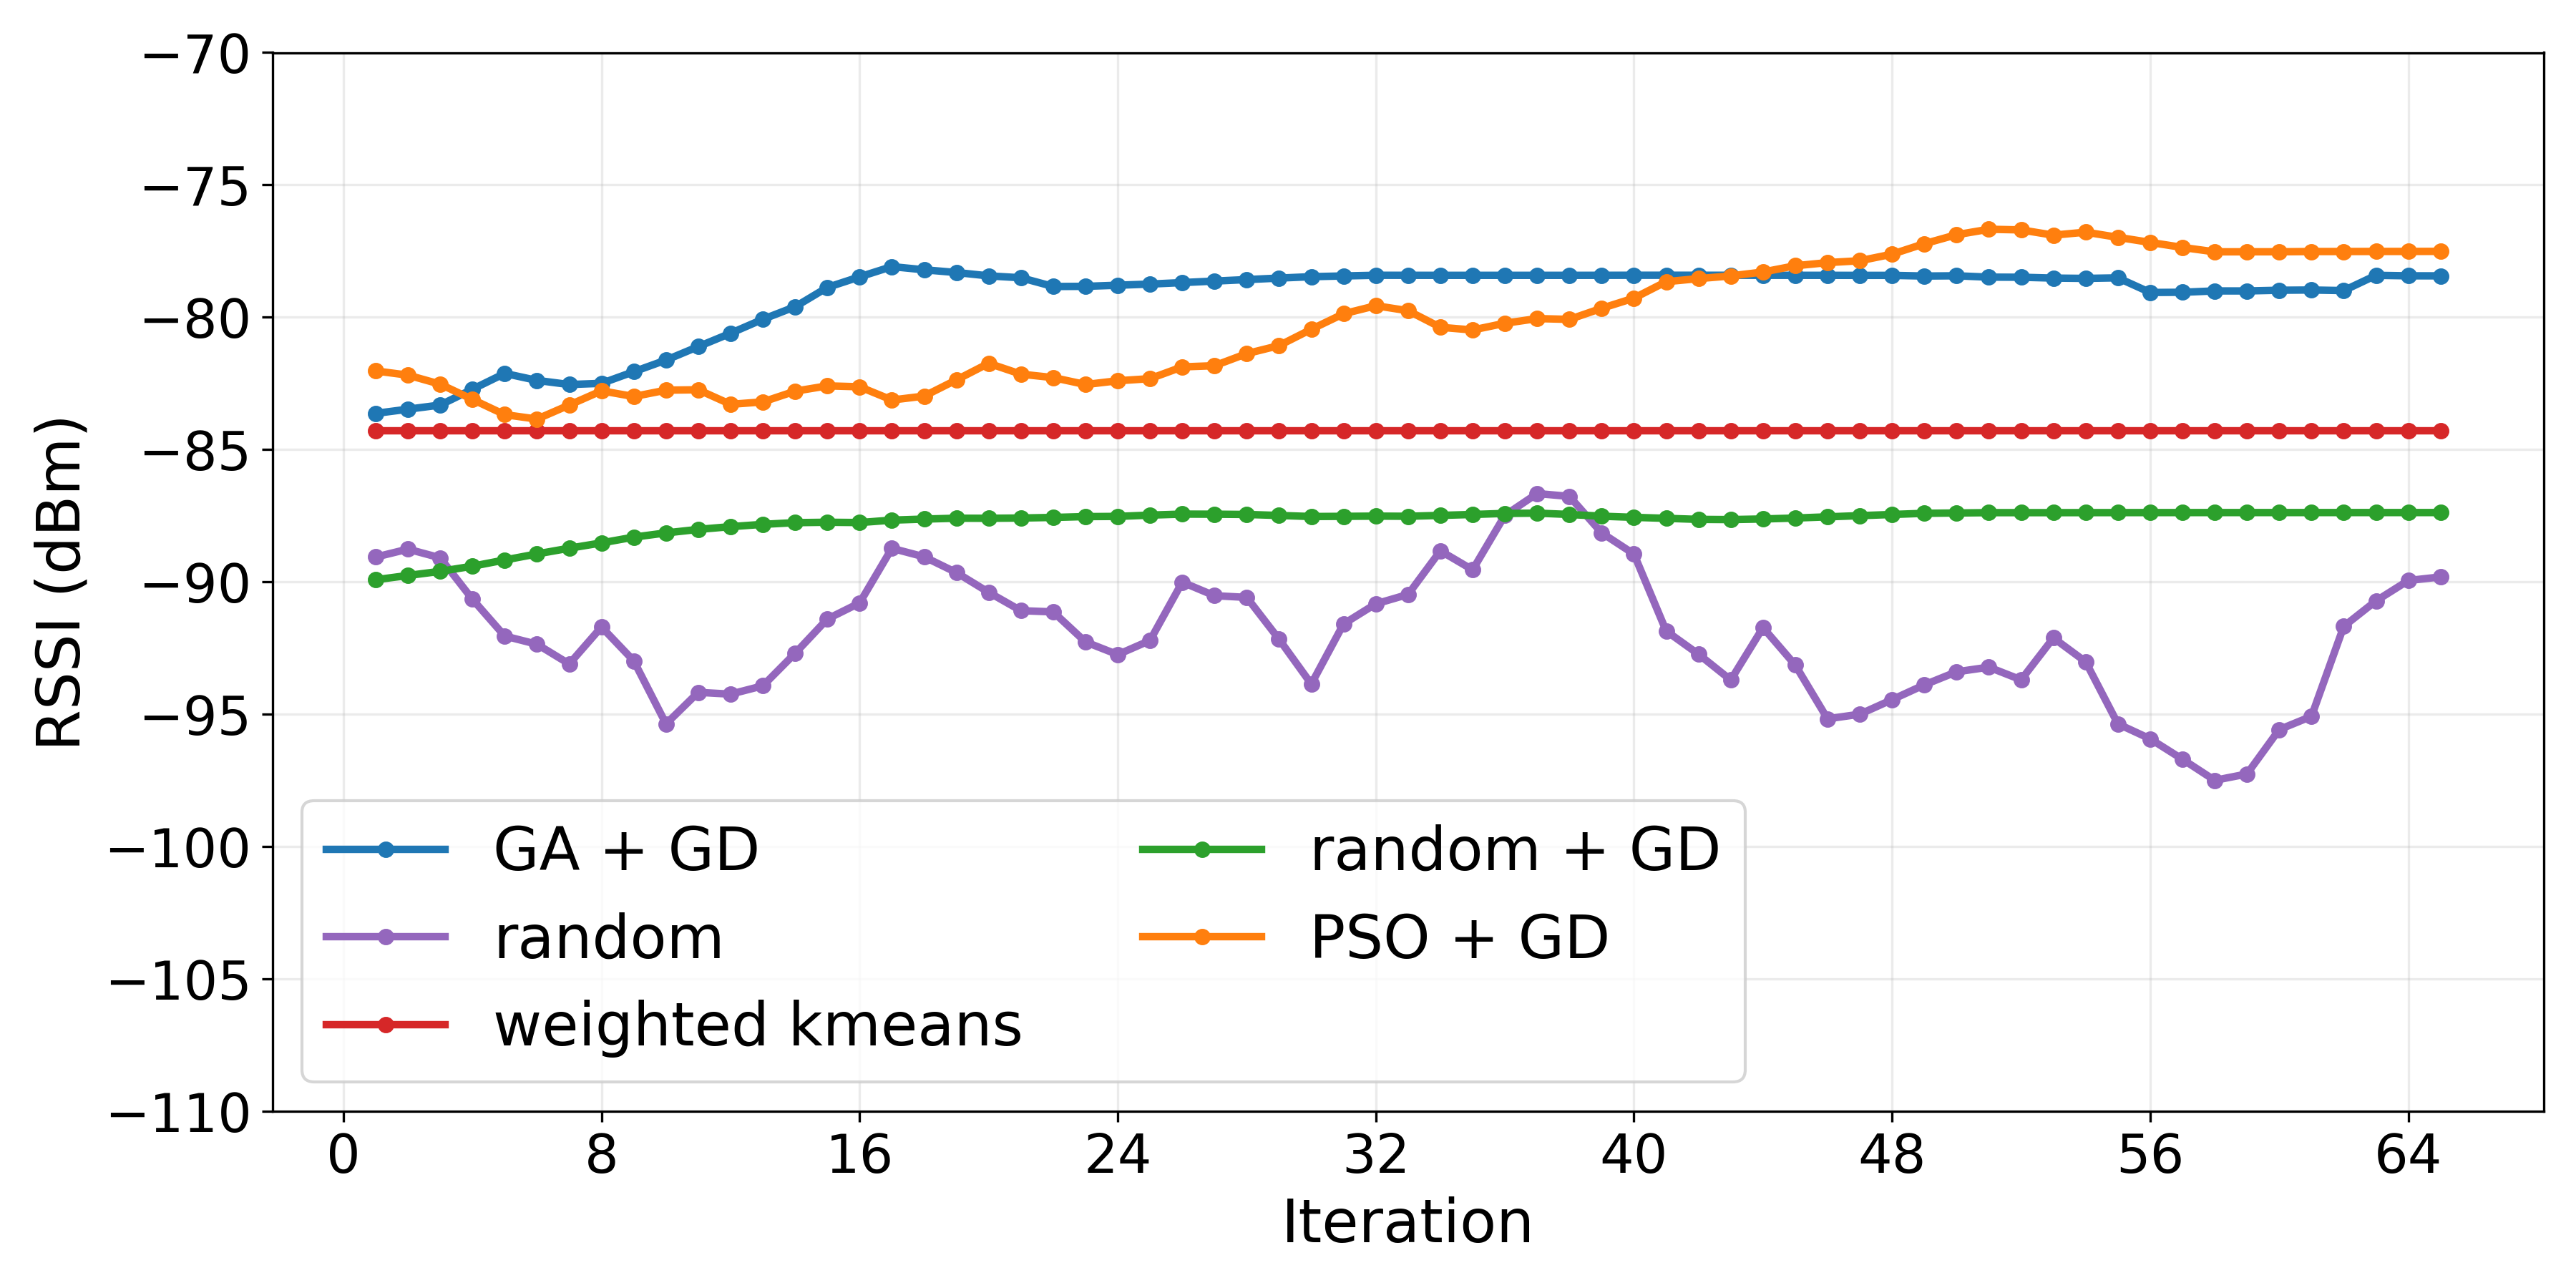

### all_methods_mean_rss_dbm_static.png

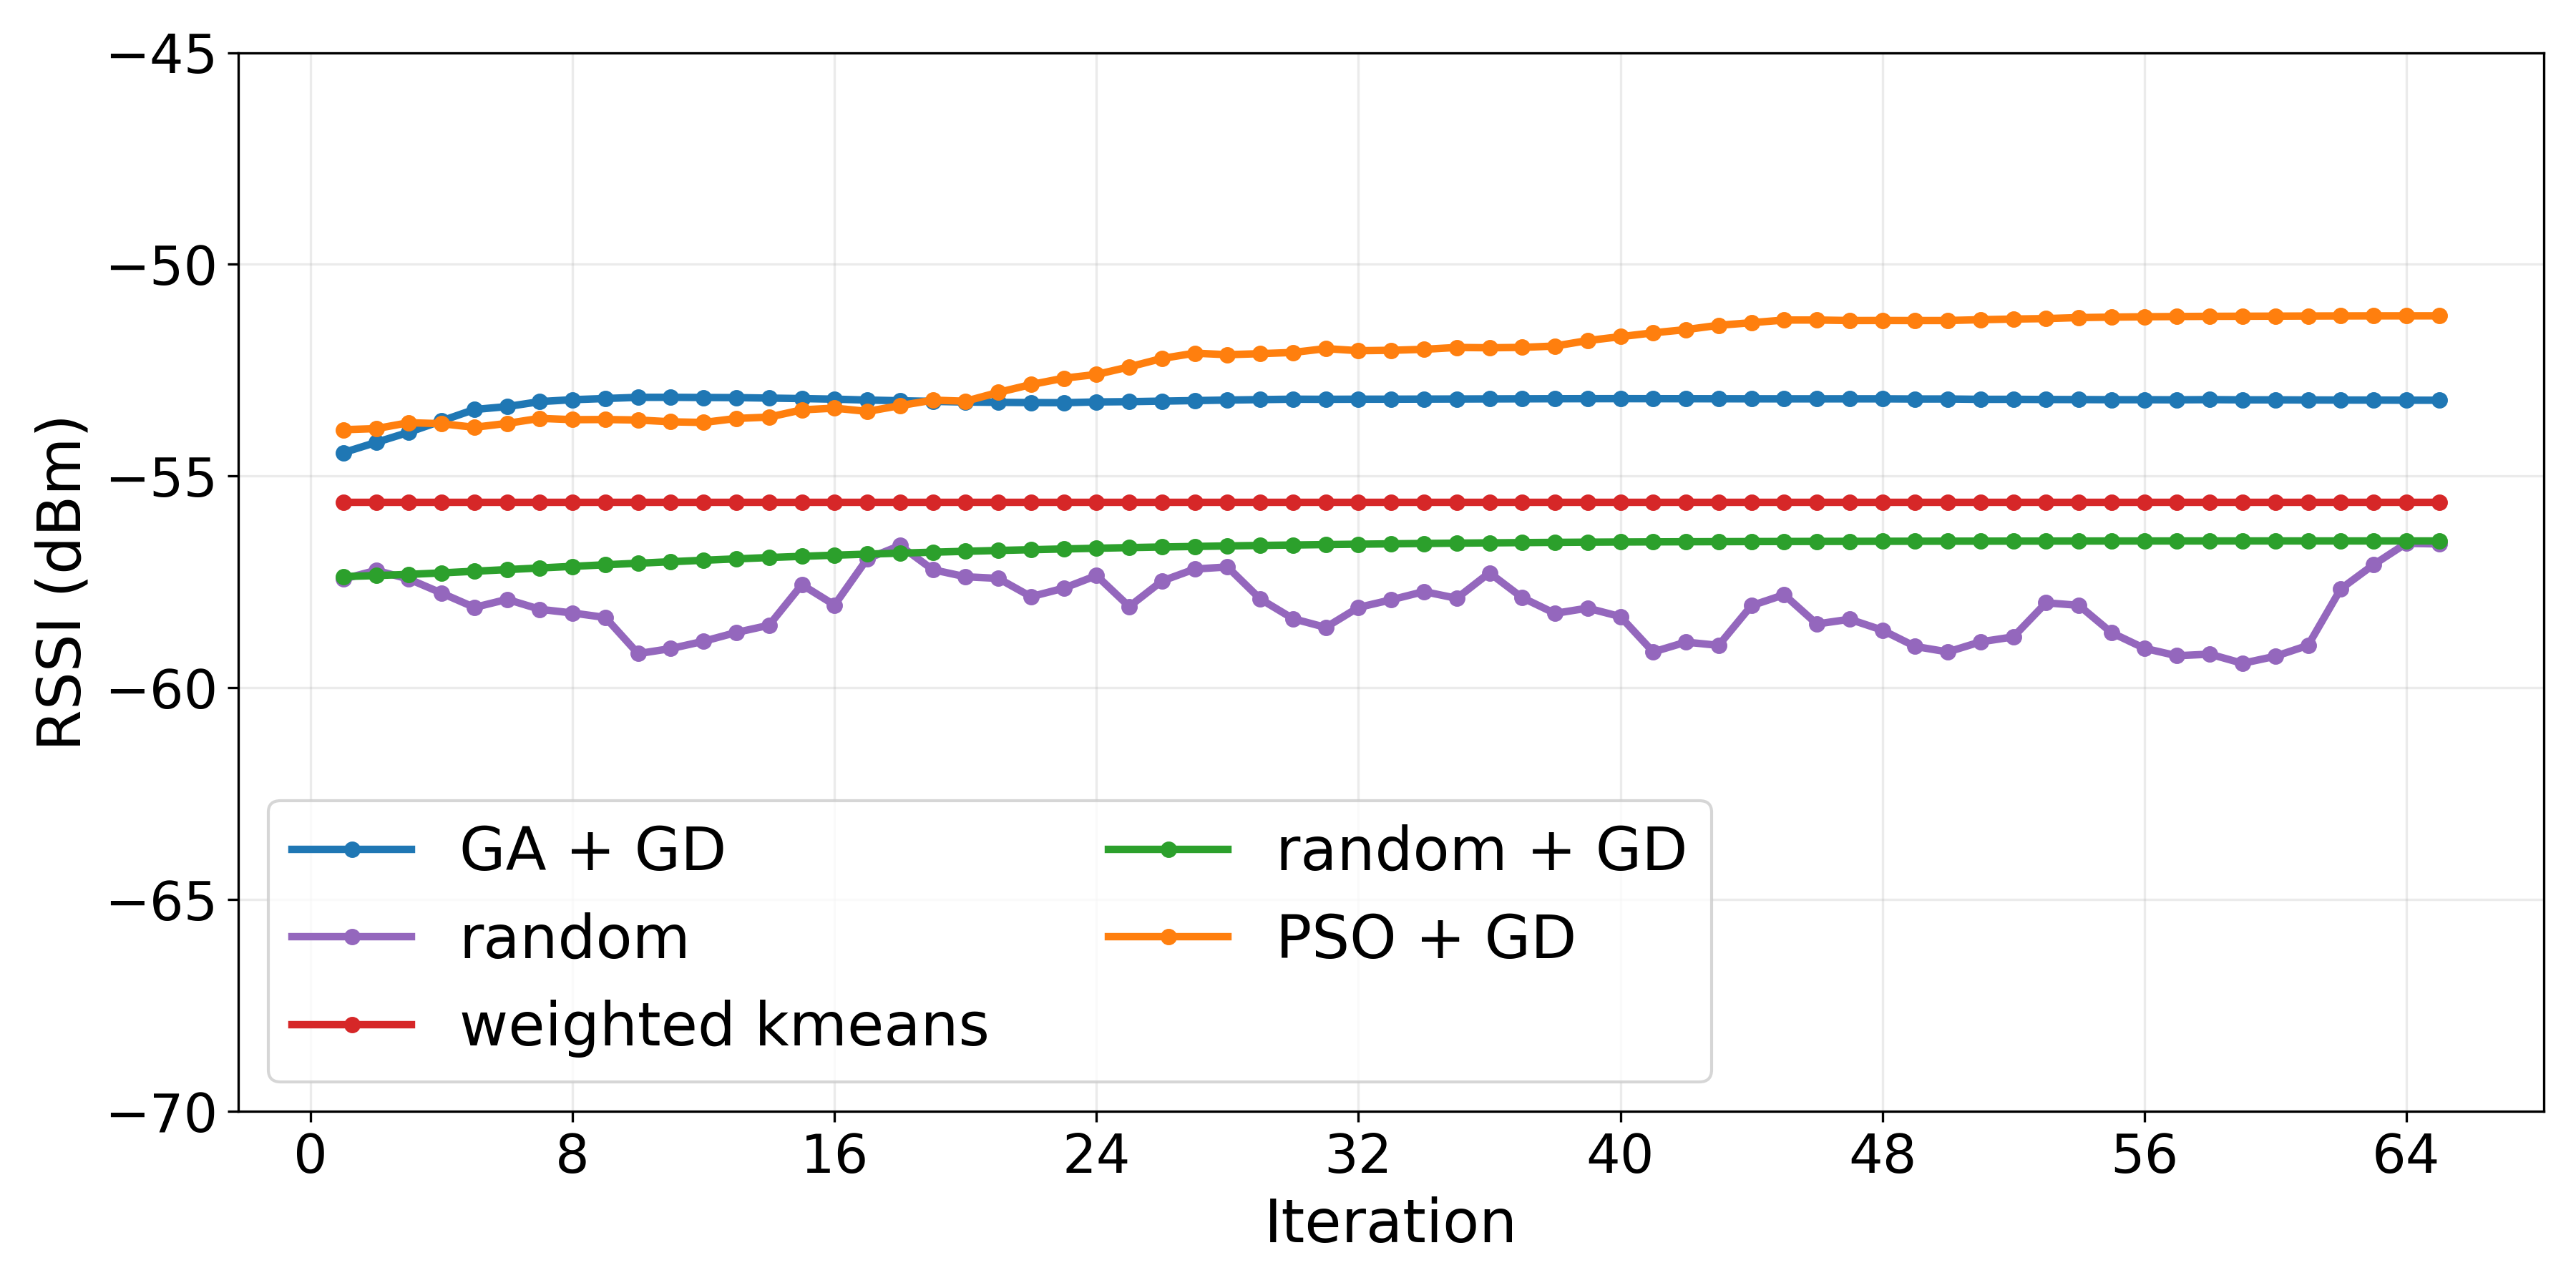

### all_methods_priority_p5_rss_dbm_static.png

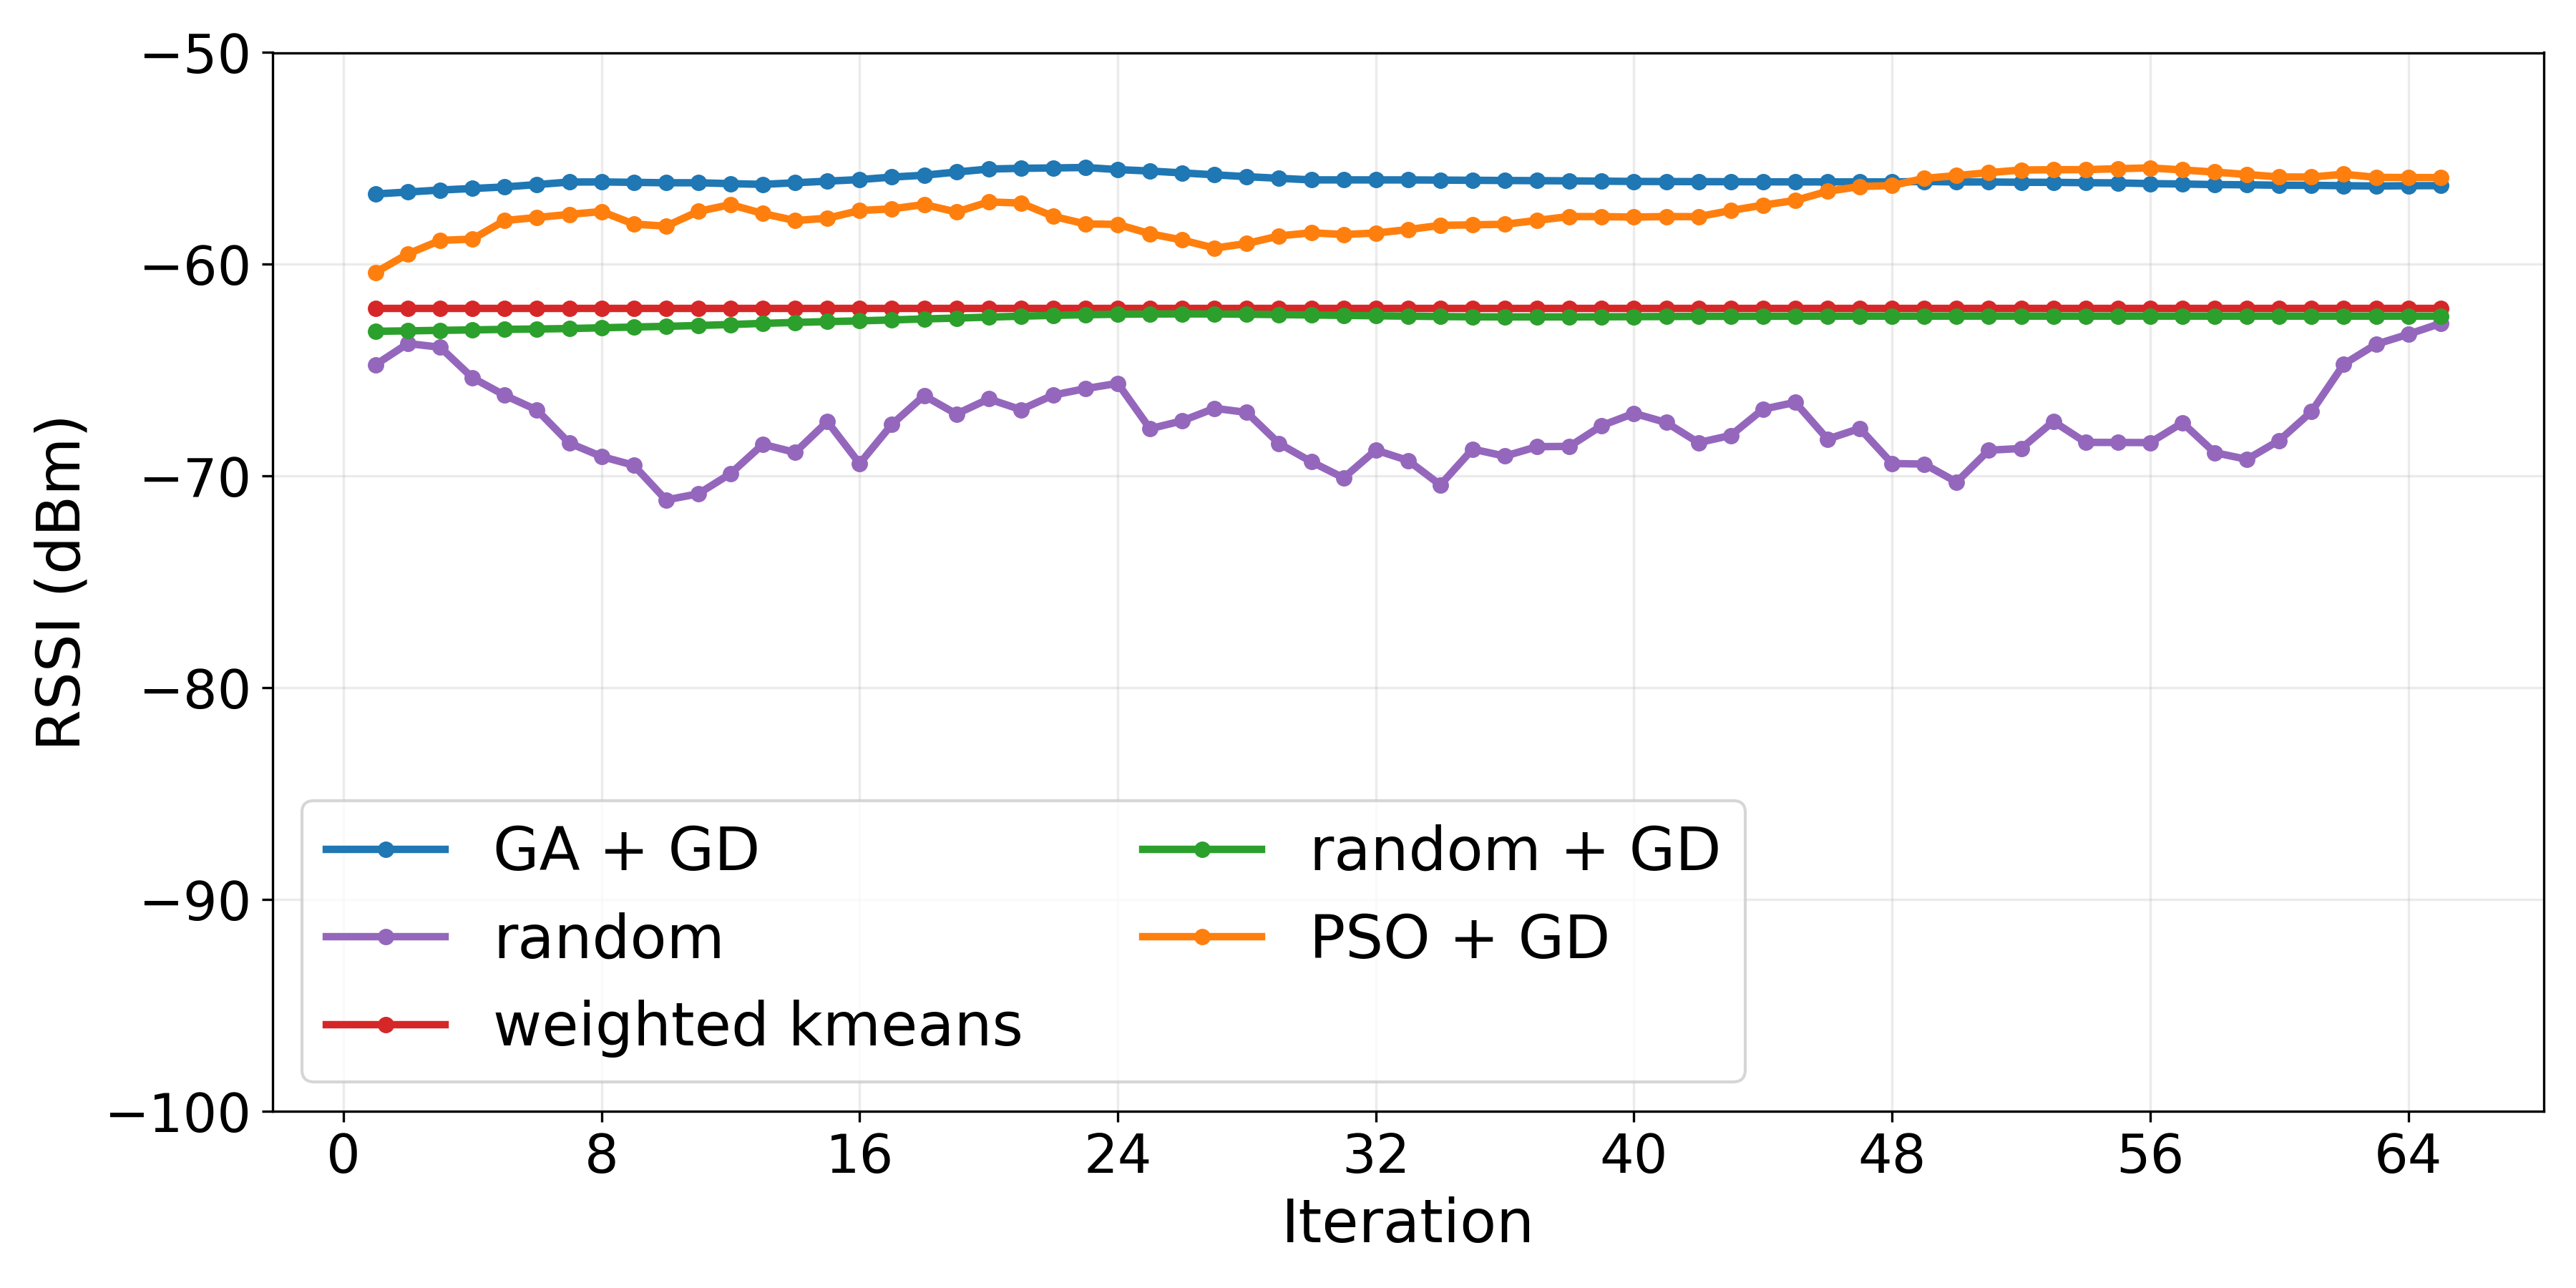

### all_methods_priority_min_rss_dbm_static.png

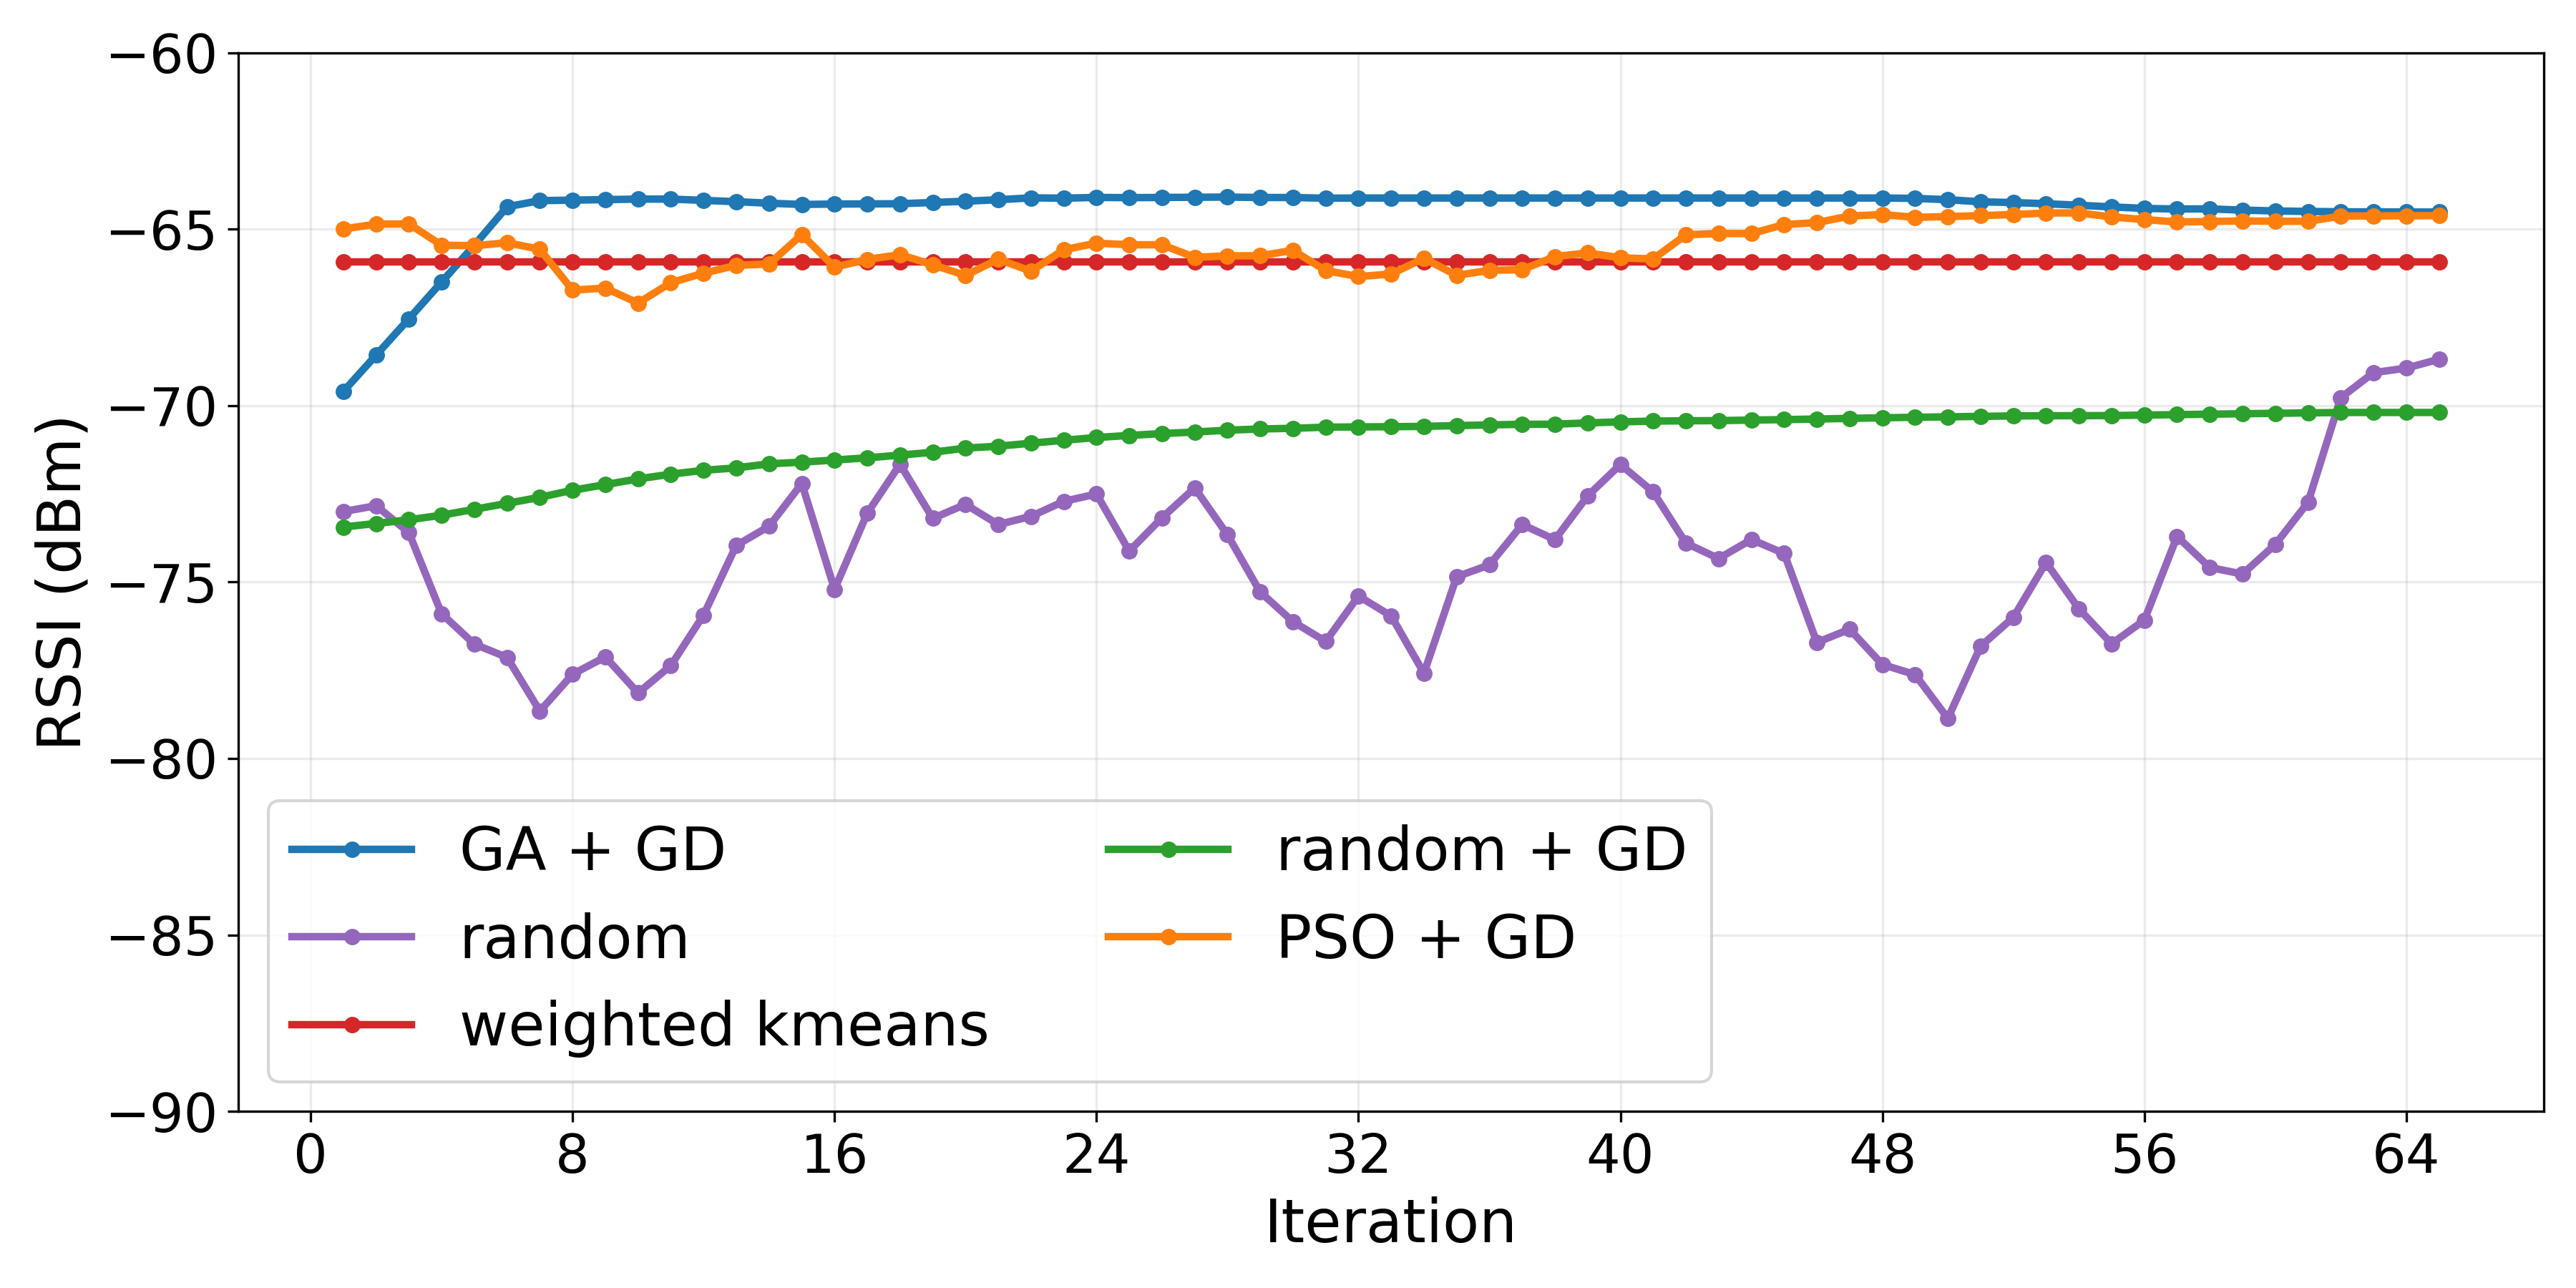

### all_methods_priority_mean_rss_dbm_static.png

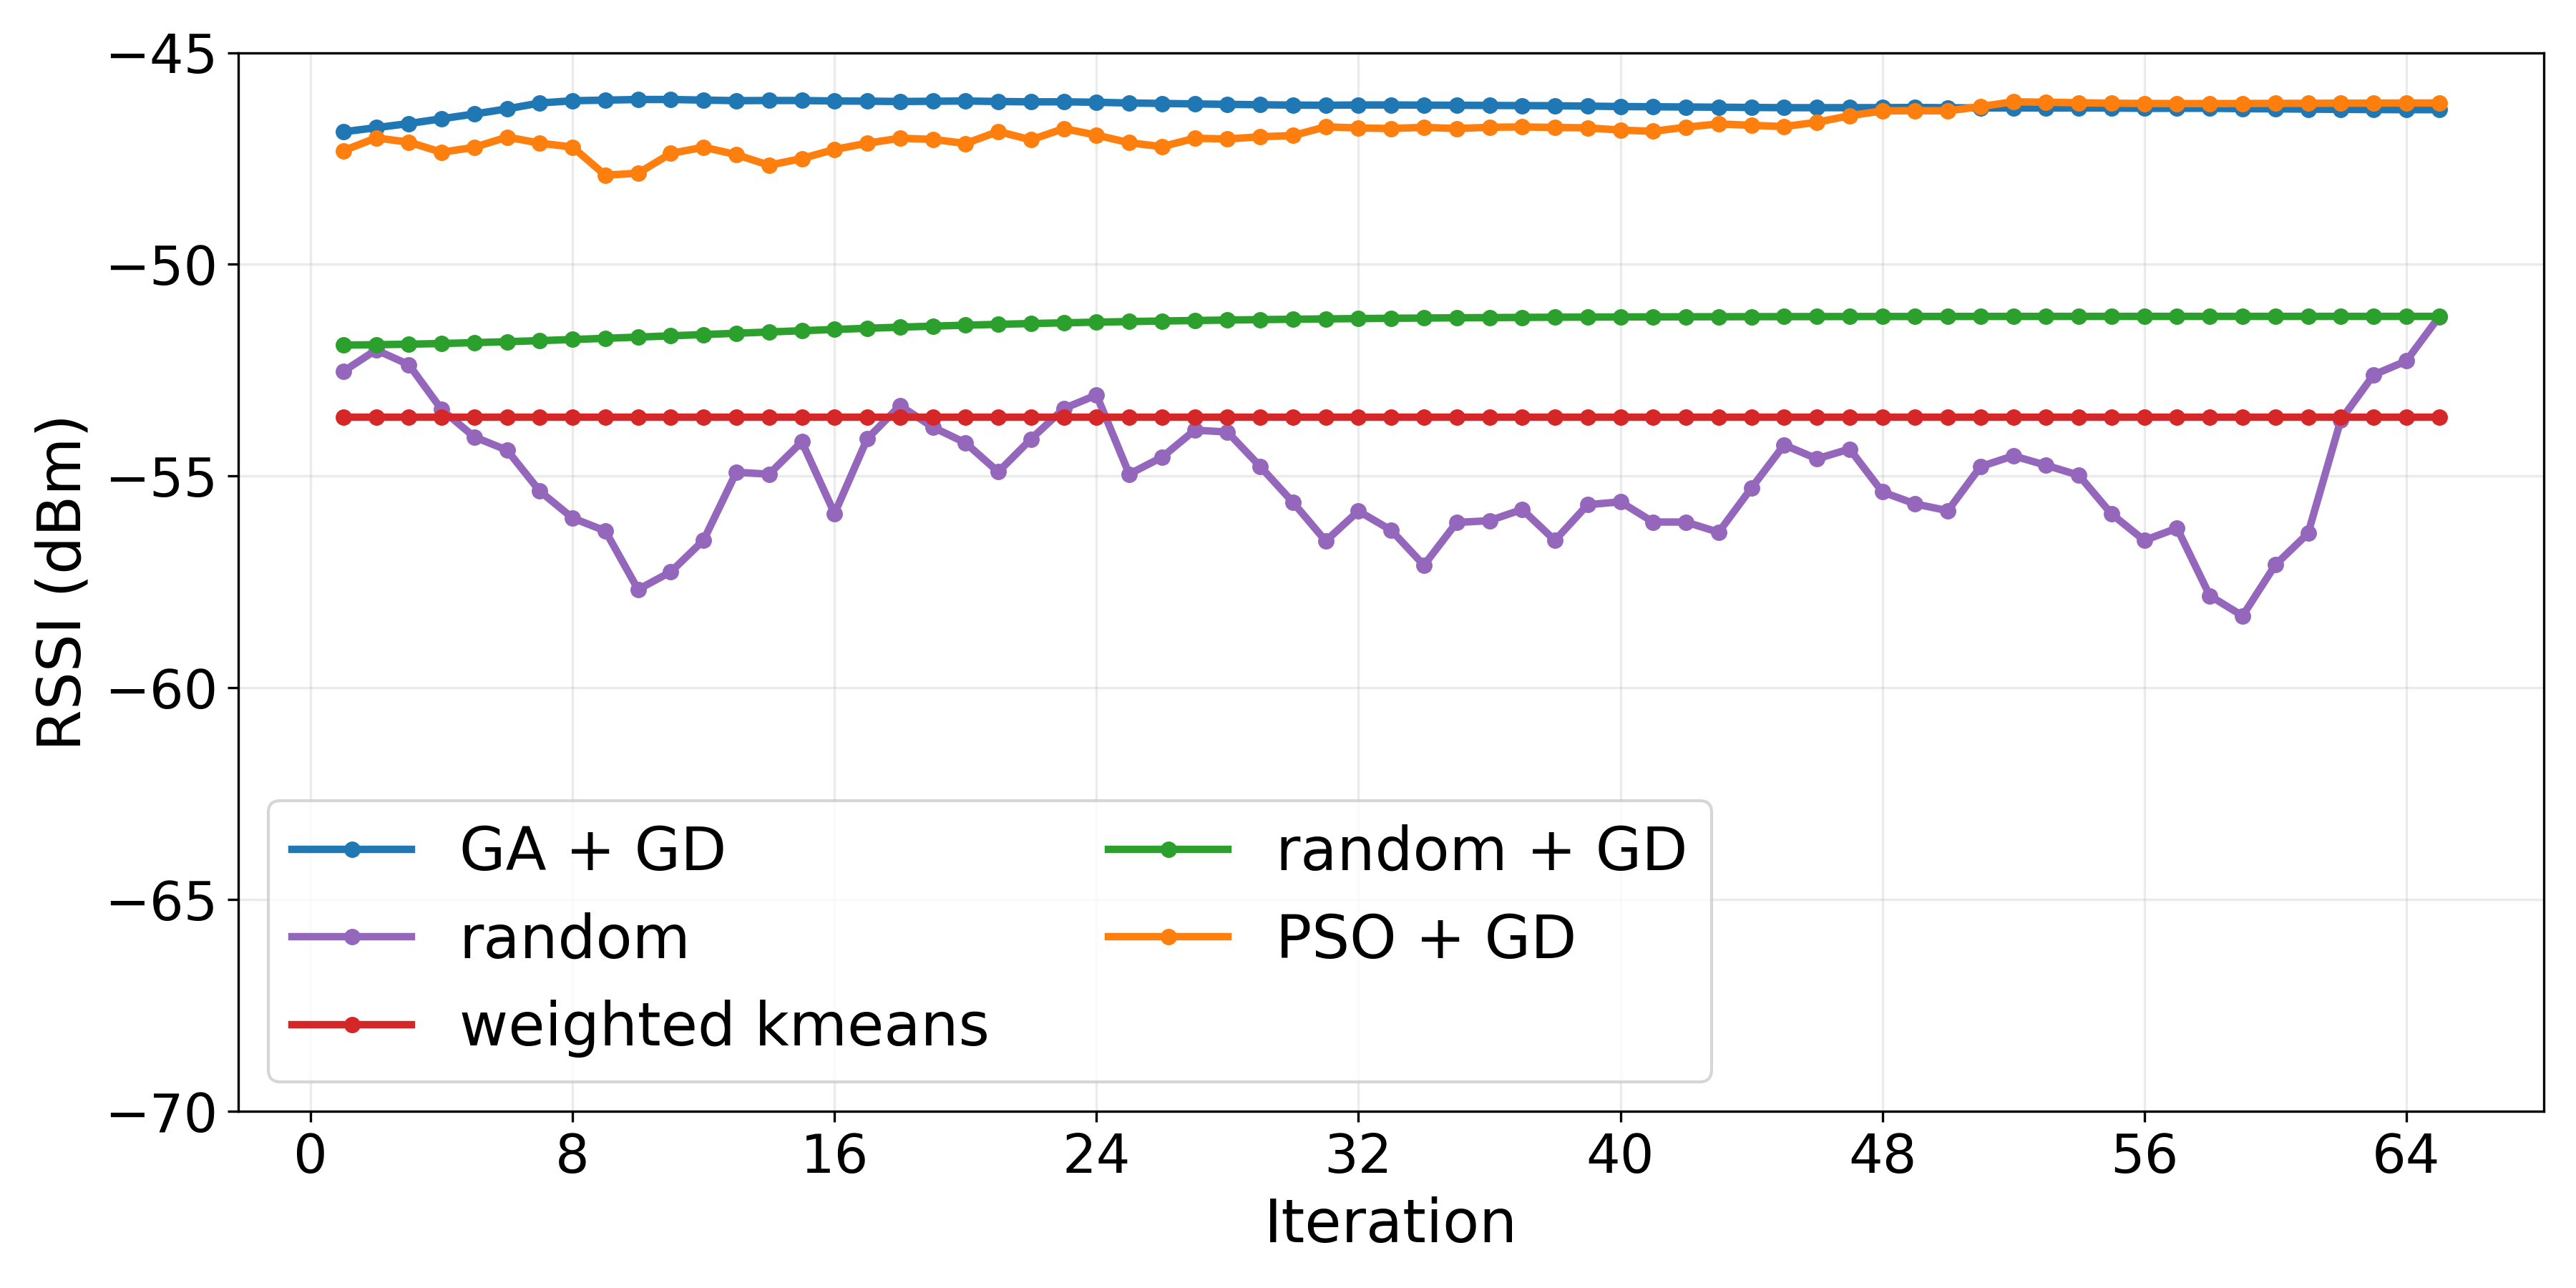

### all_methods_primary_loss_static.png

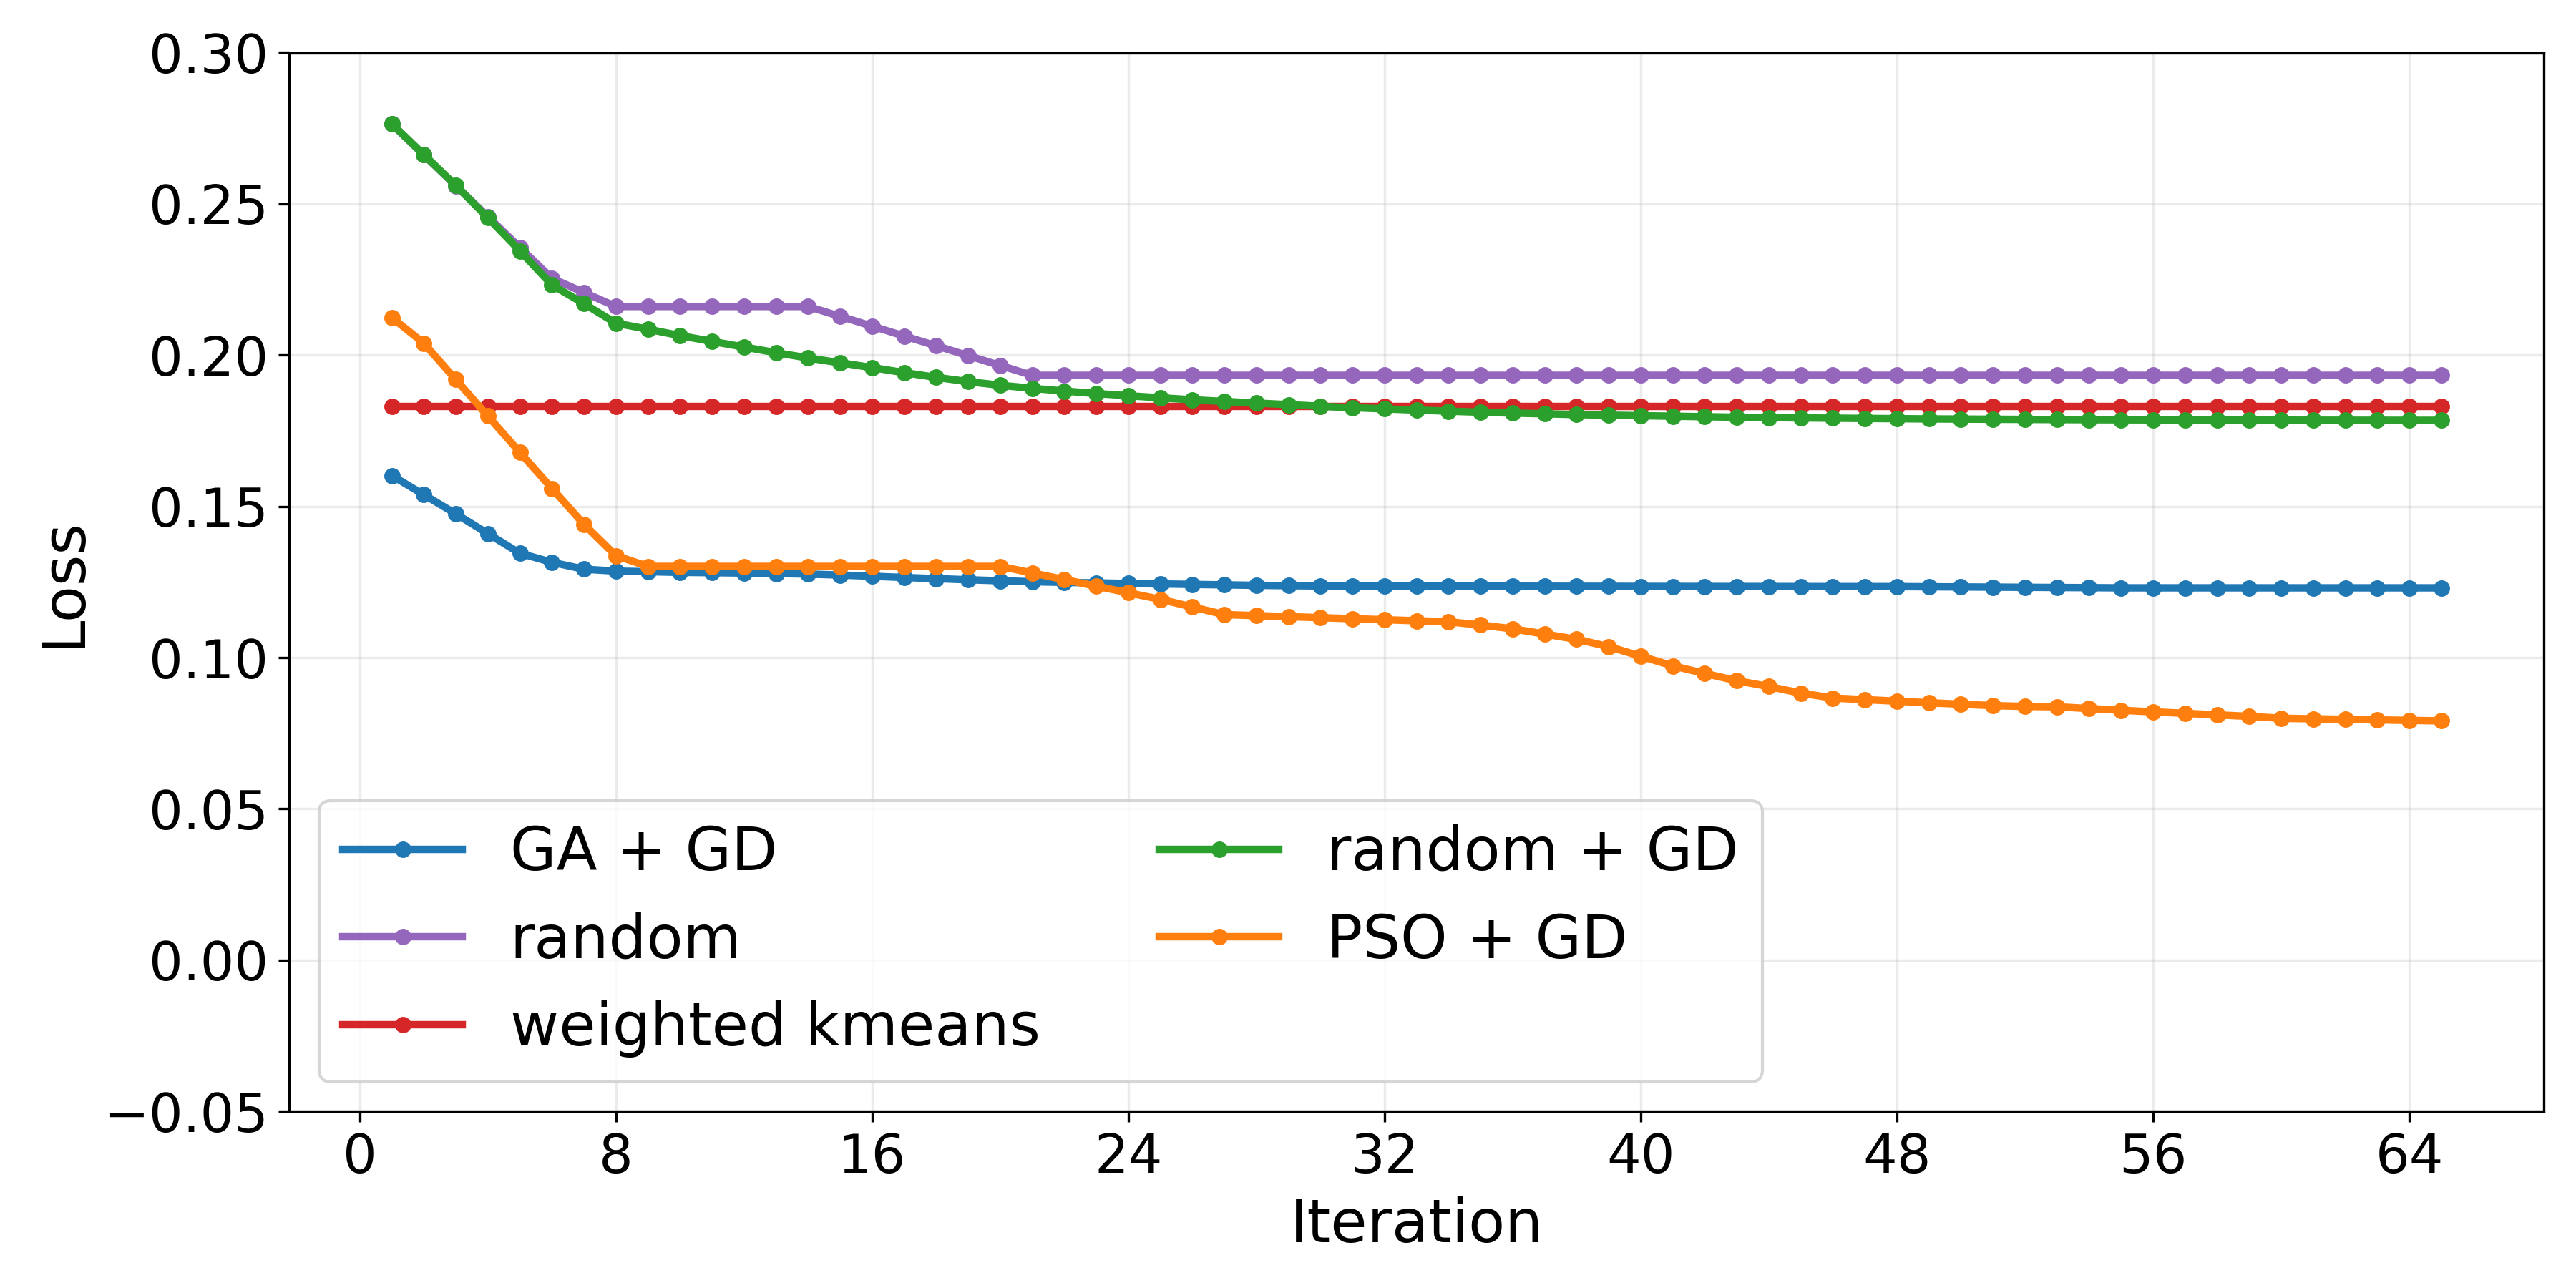

In [3]:
run_outputs = recreate_static_plots_from_trial_artifacts(
    artifacts_dir=ARTIFACTS_DIR,
    output_dir=OUTPUT_DIR,
    method_order=METHOD_ORDER,
    excluded_methods=EXCLUDED_METHODS,
    rssi_y_limits_by_plot=RSSI_Y_LIMITS_BY_PLOT,
    primary_y_limits=PRIMARY_Y_LIMITS,
    method_colors=METHOD_COLORS,
    smoothing_window=SMOOTHING_WINDOW,
)

print("Methods used:", run_outputs["methods"])
print("Output directory:", run_outputs["output_dir"])
print("Manifest:", run_outputs["manifest_path"])

display_recreated_cross_method_plots(run_outputs["plot_artifacts"])